# E-commerce Sales Analysis (Python + SQL)

**Dataset:** Olist Brazilian E-commerce (Kaggle)  |  **Tools:** Python (pandas, matplotlib), SQLite (SQL)

## Business problem
An online marketplace wants to understand its sales. This project answers:
1. How much revenue and how many orders do we have? (overall health)
2. How are sales changing month by month? (trend)
3. Which product categories earn the most? (what to focus on)
4. Which states bring the most revenue? (where our customers are)
5. How fast do we deliver? (customer experience)
6. How do customers pay? (payment behaviour)
7. How many customers come back? (loyalty)

**How this notebook works:** load CSV files into a SQL database, ask questions with **SQL**, then analyse and draw charts with **pandas**.

In [10]:
import os, shutil

needed = [
    "olist_customers_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_products_dataset.csv",
    "olist_order_payments_dataset.csv",
    "product_category_name_translation.csv",
]

os.makedirs("olist_data", exist_ok=True)
search_root = os.path.expanduser("~/Downloads")

# Look for the real files anywhere inside Downloads
found = {}
for root, folders, files in os.walk(search_root):
    for f in files:
        clean = f.replace(" (1)", "")
        path = os.path.join(root, f)
        if clean in needed and clean not in found:
            found[clean] = path

for name in needed:
    if name in found:
        shutil.copy(found[name], os.path.join("olist_data", name))
        print("FOUND and copied:", name)
    else:
        print("MISSING:", name)

FOUND and copied: olist_customers_dataset.csv
FOUND and copied: olist_orders_dataset.csv
FOUND and copied: olist_order_items_dataset.csv
FOUND and copied: olist_products_dataset.csv
FOUND and copied: olist_order_payments_dataset.csv
FOUND and copied: product_category_name_translation.csv


## Step 1: Import the libraries
Libraries are ready-made tools. `pandas` handles tables, `sqlite3` is our database, `matplotlib` draws charts.

In [11]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (10, 5)

In [12]:
files = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "products": "olist_products_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

conn = sqlite3.connect("olist.db")

for table, filename in files.items():
    df = pd.read_csv(f"olist_data/{filename}")
    df.to_sql(table, conn, if_exists="replace", index=False)
    print(f"{table}: {df.shape[0]} rows, {df.shape[1]} columns")

customers: 99441 rows, 5 columns
orders: 99441 rows, 8 columns
order_items: 112650 rows, 7 columns
products: 32951 rows, 9 columns
payments: 103886 rows, 5 columns
category_translation: 71 rows, 2 columns


## Step 2: Load the CSV files into a SQL database
Put all the Olist CSV files in a folder called `data` next to this notebook.
Each CSV becomes a **table** inside a SQLite database file (`olist.db`), just like in a real company.

## Step 3: Look at the data first
Before analysing, always check what you have. A quick look catches problems early.

In [4]:
orders = pd.read_sql("SELECT * FROM orders", conn)
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
# How many orders per status? (delivered, canceled, shipped...)
pd.read_sql("""
SELECT order_status, COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC
""", conn)

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [6]:
# Missing values in the orders table
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**Data cleaning decision:** we only analyse orders with status `delivered`, because canceled or unfinished orders do not represent real revenue.
Missing delivery dates belong to orders that were not delivered, so this filter handles them as well.

## Step 4: Overall business numbers (KPIs)
Three numbers every business tracks: total revenue, number of orders, and average order value (AOV).

In [7]:
kpi = pd.read_sql("""
SELECT
    ROUND(SUM(oi.price), 2)                               AS total_revenue,
    COUNT(DISTINCT o.order_id)                            AS total_orders,
    ROUND(SUM(oi.price) / COUNT(DISTINCT o.order_id), 2)  AS avg_order_value
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
""", conn)
kpi

,total_revenue,total_orders,avg_order_value
0,13221498.11,96478,137.04


## Step 5: Monthly sales trend
`strftime('%Y-%m', date)` cuts a date down to year-month so we can group by month.

In [8]:
monthly = pd.read_sql("""
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(oi.price), 2)                       AS revenue,
    COUNT(DISTINCT o.order_id)                    AS orders
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month
""", conn)

# The first and last months in the real Olist data are incomplete, so keep full months only
monthly = monthly[(monthly["month"] >= "2017-01") & (monthly["month"] <= "2018-08")]
monthly

,month,revenue,orders
3,2017-01,111798.36,750
4,2017-02,234223.40,1653
5,2017-03,359198.85,2546
6,2017-04,340669.68,2303
7,2017-05,489338.25,3546
8,2017-06,421923.37,3135
9,2017-07,481604.52,3872
10,2017-08,554699.70,4193
11,2017-09,607399.67,4150
12,2017-10,648247.65,4478


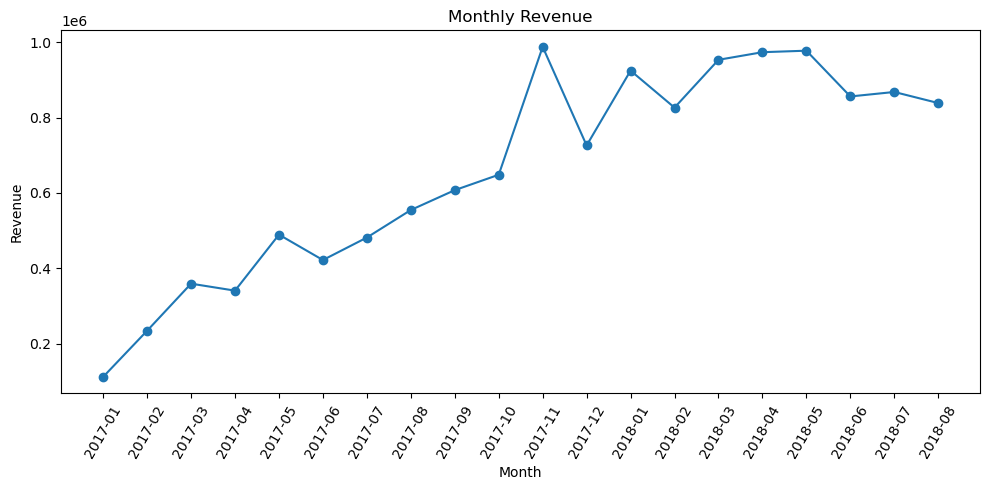

In [9]:
plt.plot(monthly["month"], monthly["revenue"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [10]:
# Month-over-month growth (%) using pandas
monthly["growth_%"] = monthly["revenue"].pct_change().mul(100).round(1)
monthly[["month", "revenue", "growth_%"]].tail(8)

,month,revenue,growth_%
15,2018-01,924645.00,27.4
16,2018-02,826437.13,-10.6
17,2018-03,953356.25,15.4
18,2018-04,973534.09,2.1
19,2018-05,977544.69,0.4
20,2018-06,856077.86,-12.4
21,2018-07,867953.46,1.4
22,2018-08,838576.64,-3.4


## Step 6: Top 10 product categories by revenue
This needs a **3-table JOIN**: order_items, products and the English translation of category names.

In [11]:
categories = pd.read_sql("""
SELECT
    COALESCE(t.product_category_name_english, 'unknown') AS category,
    ROUND(SUM(oi.price), 2)                              AS revenue,
    COUNT(DISTINCT oi.order_id)                          AS orders
FROM order_items oi
JOIN orders o   ON oi.order_id = o.order_id
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name = t.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY revenue DESC
LIMIT 10
""", conn)
categories

,category,revenue,orders
0,health_beauty,1233131.72,8647
1,watches_gifts,1166176.98,5495
2,bed_bath_table,1023434.76,9272
3,sports_leisure,954852.55,7530
4,computers_accessories,888724.61,6530
5,furniture_decor,711927.69,6307
6,housewares,615628.69,5743
7,cool_stuff,610204.10,3559
8,auto,578966.65,3810
9,toys,471286.48,3804


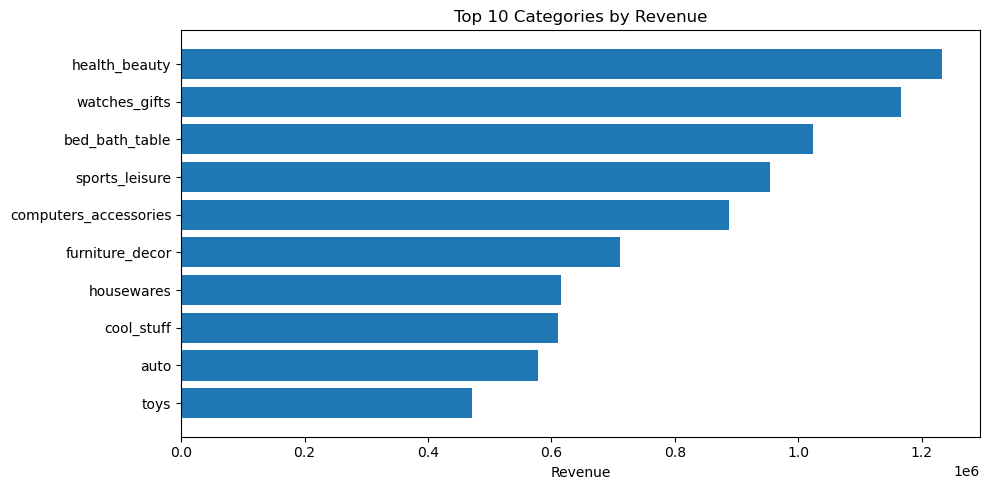

In [12]:
plt.barh(categories["category"][::-1], categories["revenue"][::-1])
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

In [13]:
# What share of total revenue do the top 10 categories make? (Pareto idea)
total = kpi["total_revenue"][0]
share = categories["revenue"].sum() / total * 100
print(f"Top 10 categories = {share:.1f}% of total revenue")

Top 10 categories = 62.4% of total revenue


## Step 7: Revenue by customer state
Where do our customers live? We join the `customers` table.

In [14]:
states = pd.read_sql("""
SELECT
    c.customer_state                AS state,
    ROUND(SUM(oi.price), 2)         AS revenue,
    COUNT(DISTINCT o.order_id)      AS orders
FROM orders o
JOIN customers c    ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY state
ORDER BY revenue DESC
LIMIT 10
""", conn)
states["revenue_share_%"] = (states["revenue"] / total * 100).round(1)
states

,state,revenue,orders,revenue_share_%
0,SP,5067633.16,40501,38.3
1,RJ,1759651.13,12350,13.3
2,MG,1552481.83,11354,11.7
3,RS,728897.47,5345,5.5
4,PR,666063.51,4923,5.0
5,SC,507012.13,3546,3.8
6,BA,493584.14,3256,3.7
7,DF,296498.41,2080,2.2
8,GO,282836.70,1957,2.1
9,ES,268643.45,1995,2.0


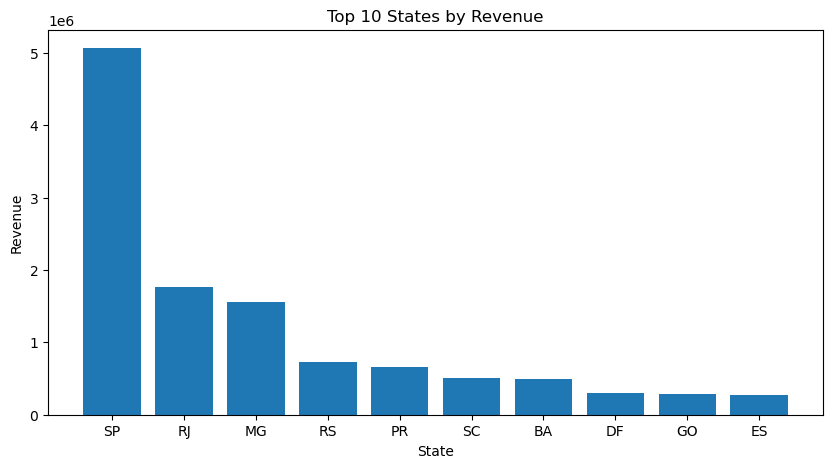

In [15]:
plt.bar(states["state"], states["revenue"])
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()

## Step 8: Delivery time
`julianday()` turns a date into a number, so subtracting two dates gives days.

In [16]:
delivery = pd.read_sql("""
SELECT
    julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) AS delivery_days,
    julianday(order_delivered_customer_date) - julianday(order_estimated_delivery_date) AS days_vs_estimate
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
""", conn)

print("Average delivery days:", round(delivery["delivery_days"].mean(), 1))
print("Median delivery days :", round(delivery["delivery_days"].median(), 1))
print("Delivered late (%)   :", round((delivery["days_vs_estimate"] > 0).mean() * 100, 1))

Average delivery days: 12.6
Median delivery days : 10.2
Delivered late (%)   : 8.1


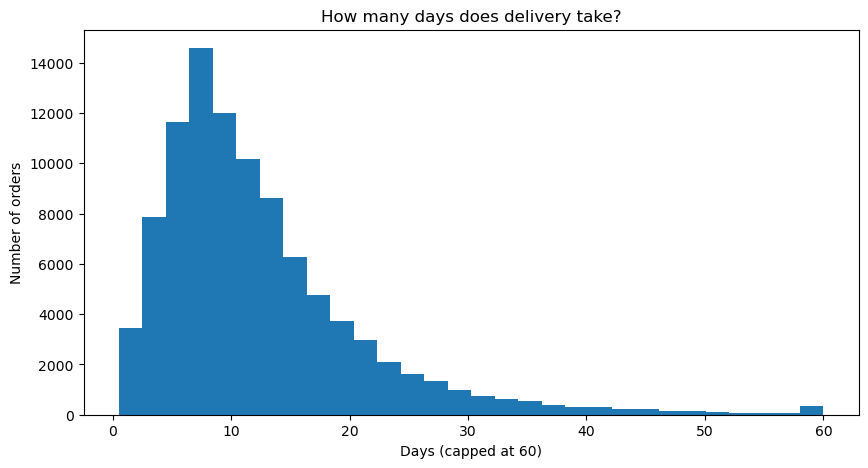

In [17]:
plt.hist(delivery["delivery_days"].clip(upper=60), bins=30)
plt.title("How many days does delivery take?")
plt.xlabel("Days (capped at 60)")
plt.ylabel("Number of orders")
plt.show()

## Step 9: Payment methods

In [18]:
payments = pd.read_sql("""
SELECT
    payment_type,
    COUNT(*)                     AS payments,
    ROUND(SUM(payment_value), 2) AS total_value
FROM payments
GROUP BY payment_type
ORDER BY total_value DESC
""", conn)
payments["share_%"] = (payments["total_value"] / payments["total_value"].sum() * 100).round(1)
payments

,payment_type,payments,total_value,share_%
0,credit_card,76795,12542084.19,78.3
1,boleto,19784,2869361.27,17.9
2,voucher,5775,379436.87,2.4
3,debit_card,1529,217989.79,1.4
4,not_defined,3,0.00,0.0


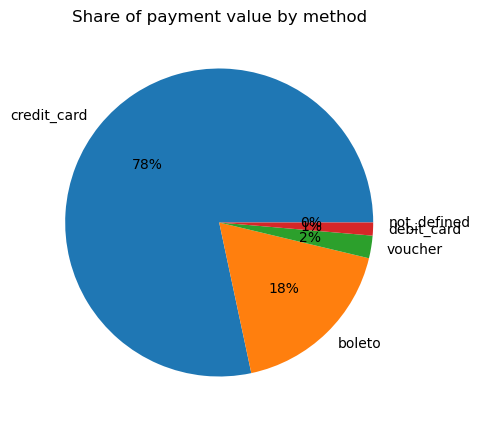

In [19]:
plt.pie(payments["total_value"], labels=payments["payment_type"], autopct="%1.0f%%")
plt.title("Share of payment value by method")
plt.show()

## Step 10: Repeat customers
`customer_id` changes with every order in Olist, so the real customer is identified by `customer_unique_id`.

In [20]:
repeat = pd.read_sql("""
SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
""", conn)

repeat_rate = (repeat["orders"] > 1).mean() * 100
print(f"Customers: {len(repeat)}")
print(f"Repeat customers (2+ orders): {repeat_rate:.1f}%")

Customers: 93358
Repeat customers (2+ orders): 3.0%


## Step 11: Key insights (write these in YOUR words)
Run the notebook on the real data, look at your numbers, and fill in the blanks. Recruiters read this section first.

1. **Revenue and orders:** Total revenue is 13221498.11 from 96478 orders, with an average order value of 137.04.
2. **Trend:** Revenue grew from 111798.36 in January 2017 to 838576.64 in August 2018. The best month was November 2017. Possibly due to Black Friday Sales.
3. **Categories:** The top category is health_beauty. The top 10 categories give 62.4% of revenue.
4. **Geography:** SP (state) alone brings 38.3% of revenue. Some states have very low sales.
5. **Delivery:** Average delivery takes 12.6 days and 8.1% of orders arrive later than promised.
6. **Payments:** credit_card is the most used payment method (78.3%).
7. **Loyalty:** Only 3.0% of customers order more than once.

## Step 12: Recommendations
- **Focus on top categories:** health_beauty is the top category, and the top 10 categories give 62.4% of revenue. The company should focus stock, ads and seller support on these categories and review the weakest ones before spending more on them.
- **Prepare for peak season:** Revenue peaked in November 2017. The company should prepare stock, delivery capacity and ad budget before November every year.
- **Reduce dependence on one state:** SP alone brings 38.3% of revenue. The company should protect this market and test promotions or faster delivery in other states.
- **Improve delivery reliability:** 8.1% of orders arrive later than promised, and delivery takes 12.6 days on average. The company should work with carriers on the slowest routes and give more realistic delivery dates, because late delivery hurts customer satisfaction and repeat purchases.
- **Build customer loyalty:** Only 3.0% of customers order more than once. The company should send follow-up emails and offer a small discount on the second purchase.
- **Keep credit card checkout smooth:** Credit cards make up 78.3% of payment value. The company should keep this checkout fast and reliable and offer clear installment options.

## Limitations
- The dataset covers orders from late 2016 to October 2018. Monthly trends use only full months (January 2017 to August 2018), because 2016 has very few orders and the last months of 2018 are incomplete.
- Only delivered orders are analysed, so canceled and unfinished orders are excluded.
- Revenue uses product price and excludes shipping (`freight_value`). It does not account for discounts or refunds.
- There is no cost data, so profit cannot be calculated.
- The data comes from one marketplace in Brazil, so the findings may not apply to other markets.
- The repeat customer rate (3.0%) covers a short period of about two years, and customers could have returned later.
- Late deliveries are measured against the estimated delivery date given at purchase, not against what customers expected.

In [21]:
conn.close()

In [22]:
!pip install sqlalchemy pymysql

In [24]:
import os
print(os.path.abspath("ecommerce_sales_analysis.ipynb"))
os.startfile(os.getcwd())

C:\Users\DELL\Downloads\ecommerce_sales_analysis.ipynb
